In [8]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from tqdm.notebook import tqdm

from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [10]:
df = pd.read_csv('/content/cybersequrity.csv')
print('Размер датасета:', df.shape)

# Делим на признаки и целевую переменную
features = df.drop(columns=['Class'])
labels = df['Class']
n_features = features.shape[1]
print('Число признаков:', n_features)

# Train / Val / Test
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

# Стандартизуем
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Train/Val/Test:', X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Размер датасета: (10000, 16)
Число признаков: 15
Train/Val/Test: (6000, 15) (2000, 15) (2000, 15)


In [11]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, "values") else y,
                              dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [12]:
train_dataset = CustomDataset(X_train_scaled, y_train)
val_dataset = CustomDataset(X_val_scaled, y_val)
test_dataset = CustomDataset(X_test_scaled, y_test)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
class MLP(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size, n_linear_layers=3, activation=nn.ReLU):
        super(MLP, self).__init__()

        layers = [nn.Linear(input_size, hidden_size), activation()]

        for i in range(n_linear_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(activation())

        layers.append(nn.Linear(hidden_size, num_labels))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred

In [15]:
# Функция обучения: проходим по эпохам и батчам, считаем лосс и метрики
def train_model(model, num_epochs=100, eval_freq=10):
    history = {
        'train_loss': [],
        'train_f1': [],
        'val_loss': [],
        'val_f1': [],
    }

    global_step = 0
    model.train()

    for epoch in tqdm(range(num_epochs), desc='Обучение'):
        for batch_X, target in train_loader:
            optimizer.zero_grad()

            preds_proba = model(batch_X.to(device))
            loss = loss_function(preds_proba, target.to(device))
            loss.backward()
            optimizer.step()

            # Метрики на train батче
            preds = (preds_proba >= 0.5).int().cpu().tolist()
            f1 = f1_score(preds, target.cpu().numpy().tolist())

            history['train_loss'].append((global_step, loss.item()))
            history['train_f1'].append((global_step, f1))

            # Периодически проверяем на валидации
            if global_step % eval_freq == 0:
                val_loss, val_f1 = evaluate(model, mode='val')
                history['val_loss'].append((global_step, val_loss))
                history['val_f1'].append((global_step, val_f1))
                model.train()

            global_step += 1

    return model, history

In [16]:
# Функция оценки модели на валидации или тесте
@torch.no_grad()
def evaluate(model, mode='val'):
    model.eval()

    loader = val_loader if mode == 'val' else test_loader

    total_loss = 0.0
    total_samples = 0
    all_preds = []
    all_targets = []

    for batch_X, target in loader:
        preds_proba = model(batch_X.to(device))
        loss = loss_function(preds_proba, target.to(device))

        batch_size = preds_proba.shape[0]
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        preds = (preds_proba >= 0.5).int().cpu().tolist()
        all_preds += preds
        all_targets += target.cpu().numpy().tolist()

    avg_loss = total_loss / total_samples
    f1 = f1_score(all_targets, all_preds)

    return avg_loss, f1


# Функция для рисования графиков обучения
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Loss
    if history['train_loss']:
        steps, losses = zip(*history['train_loss'])
        ax1.plot(steps, losses, alpha=0.6, label='Train Loss')
    if history['val_loss']:
        steps, losses = zip(*history['val_loss'])
        ax1.plot(steps, losses, color='red', linewidth=2, label='Val Loss')
    ax1.set_xlabel('Шаг обучения')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # F1
    if history['train_f1']:
        steps, f1s = zip(*history['train_f1'])
        ax2.plot(steps, f1s, alpha=0.6, label='Train F1')
    if history['val_f1']:
        steps, f1s = zip(*history['val_f1'])
        ax2.plot(steps, f1s, color='red', linewidth=2, label='Val F1')
    ax2.set_xlabel('Шаг обучения')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [17]:
# Эксп 1: простая MLP (3 слоя по 15 нейронов)
model = MLP(num_labels=1, input_size=n_features, hidden_size=15, n_linear_layers=3)
model.to(device)

loss_function = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

print('Параметров в модели:', sum(p.numel() for p in model.parameters()))

Параметров в модели: 736


Обучение:   0%|          | 0/100 [00:00<?, ?it/s]

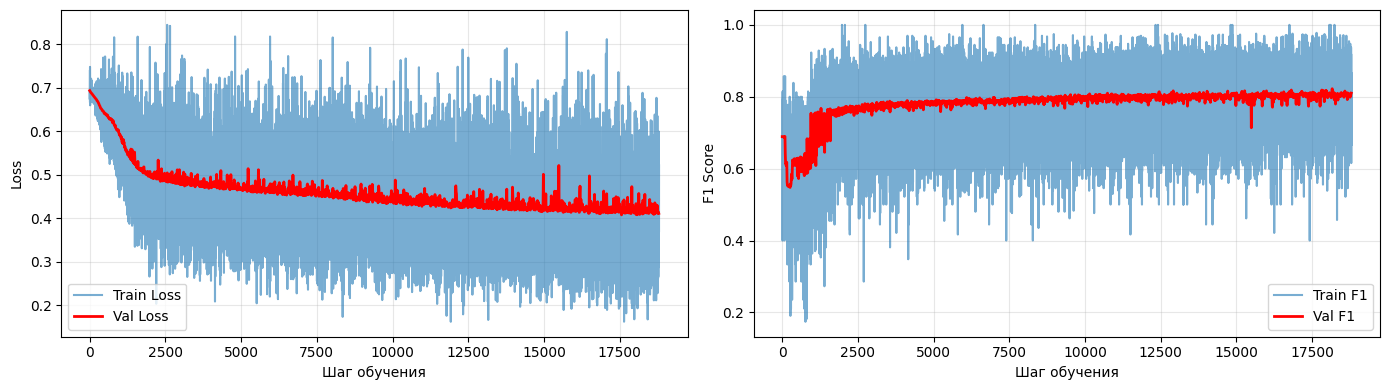

In [18]:
model, history = train_model(model, num_epochs=100)
plot_history(history)

In [19]:
test_loss, test_f1 = evaluate(model, mode='test')
print(f'Test Loss: {test_loss:.4f} | Test F1: {test_f1:.4f}')

Test Loss: 0.3755 | Test F1: 0.8310


In [20]:
class ImprovedMLP(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size=(128, 64, 32), dropout_p=0.2, activation=nn.ReLU):
        super().__init__()
        layers = []
        layers += [
            nn.Linear(input_size, hidden_size[0]),
            nn.BatchNorm1d(hidden_size[0]),
            activation(),
            nn.Dropout(dropout_p),
        ]

        for h_in, h_out in zip(hidden_size[:-2], hidden_size[1:-1]):
            layers += [
                nn.Linear(h_in, h_out),
                nn.BatchNorm1d(h_out),
                activation(),
                nn.Dropout(dropout_p),
            ]

        layers += [
            nn.Linear(hidden_size[-2], hidden_size[-1]),
            activation(),
            nn.Dropout(dropout_p),
        ]

        layers.append(nn.Linear(hidden_size[-1], num_labels))
        self.layers = nn.Sequential(*layers)


    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred

In [21]:
# Эксп 2: улучшенная модель (BatchNorm + Dropout)
model = ImprovedMLP(num_labels=1, input_size=n_features)
model.to(device)

loss_function = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

print('Параметров в модели:', sum(p.numel() for p in model.parameters()))

Параметров в модели: 12801


Обучение:   0%|          | 0/100 [00:00<?, ?it/s]

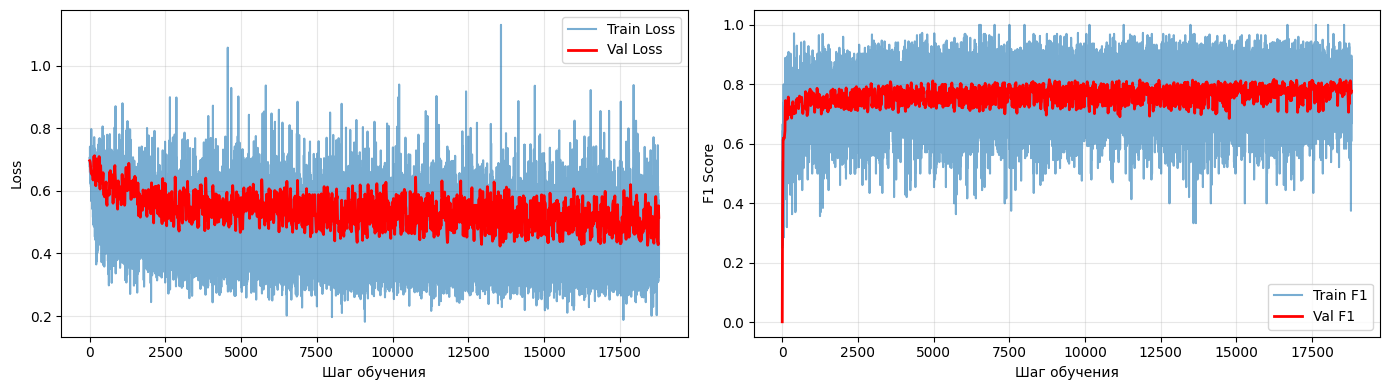

In [22]:
model, history = train_model(model, num_epochs=100)
plot_history(history)

In [23]:
test_loss, test_f1 = evaluate(model, mode='test')
print(f'Test Loss: {test_loss:.4f} | Test F1: {test_f1:.4f}')

Test Loss: 0.4522 | Test F1: 0.7914


In [24]:
# Эксп 3: batch_size=128
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

model = ImprovedMLP(num_labels=1, input_size=n_features)
model.to(device)

loss_function = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

print('Параметров в модели:', sum(p.numel() for p in model.parameters()))

Параметров в модели: 12801


Обучение:   0%|          | 0/150 [00:00<?, ?it/s]

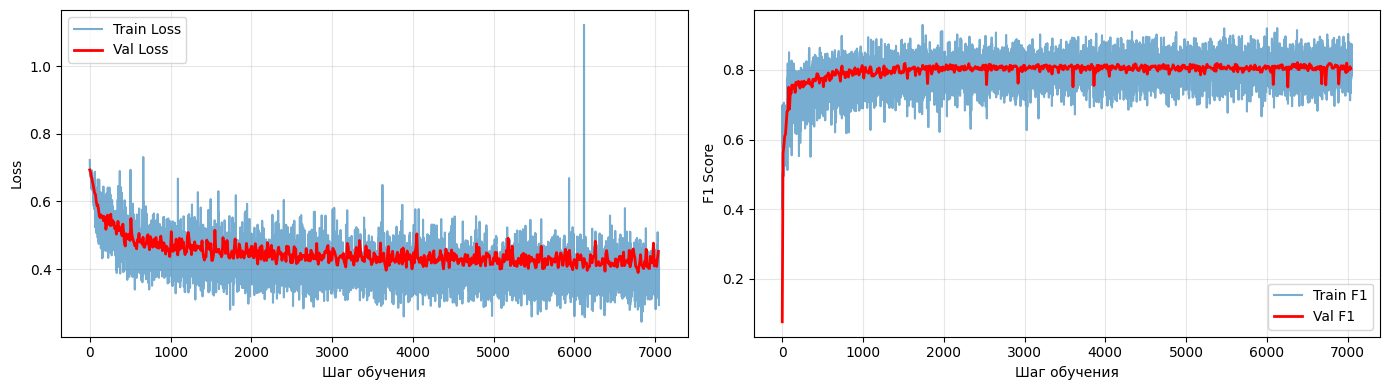

In [25]:
model, history = train_model(model, num_epochs=150)
plot_history(history)

In [26]:
test_loss, test_f1 = evaluate(model, mode='test')
print(f'Test Loss: {test_loss:.4f} | Test F1: {test_f1:.4f}')

Test Loss: 0.3758 | Test F1: 0.8274
